=== Paramètres Physiques Calculés ===
A = -0.5000
B = 0.4728
-> Régime : Basculement (Flipping)
Indices des points data sélectionnés : [  0 124 249 374 499]
Temps correspondants : [0.0, 4.969939708709717, 9.979959487915039, 14.98997974395752, 20.0]

=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===
Epoch     1 | Loss Globale: 1.6359e-01 | Loss Phys: 1.1457e-01 | Loss Data: 4.4270e-02
Epoch    10 | Loss Globale: 5.0441e-04 | Loss Phys: 4.8455e-04 | Loss Data: 1.9854e-05
Epoch    20 | Loss Globale: 2.8807e-05 | Loss Phys: 2.7733e-05 | Loss Data: 1.0744e-06
Epoch    30 | Loss Globale: 8.5807e-06 | Loss Phys: 8.4135e-06 | Loss Data: 1.6696e-07
>>> Génération et affichage des graphiques pour l'epoch 30...


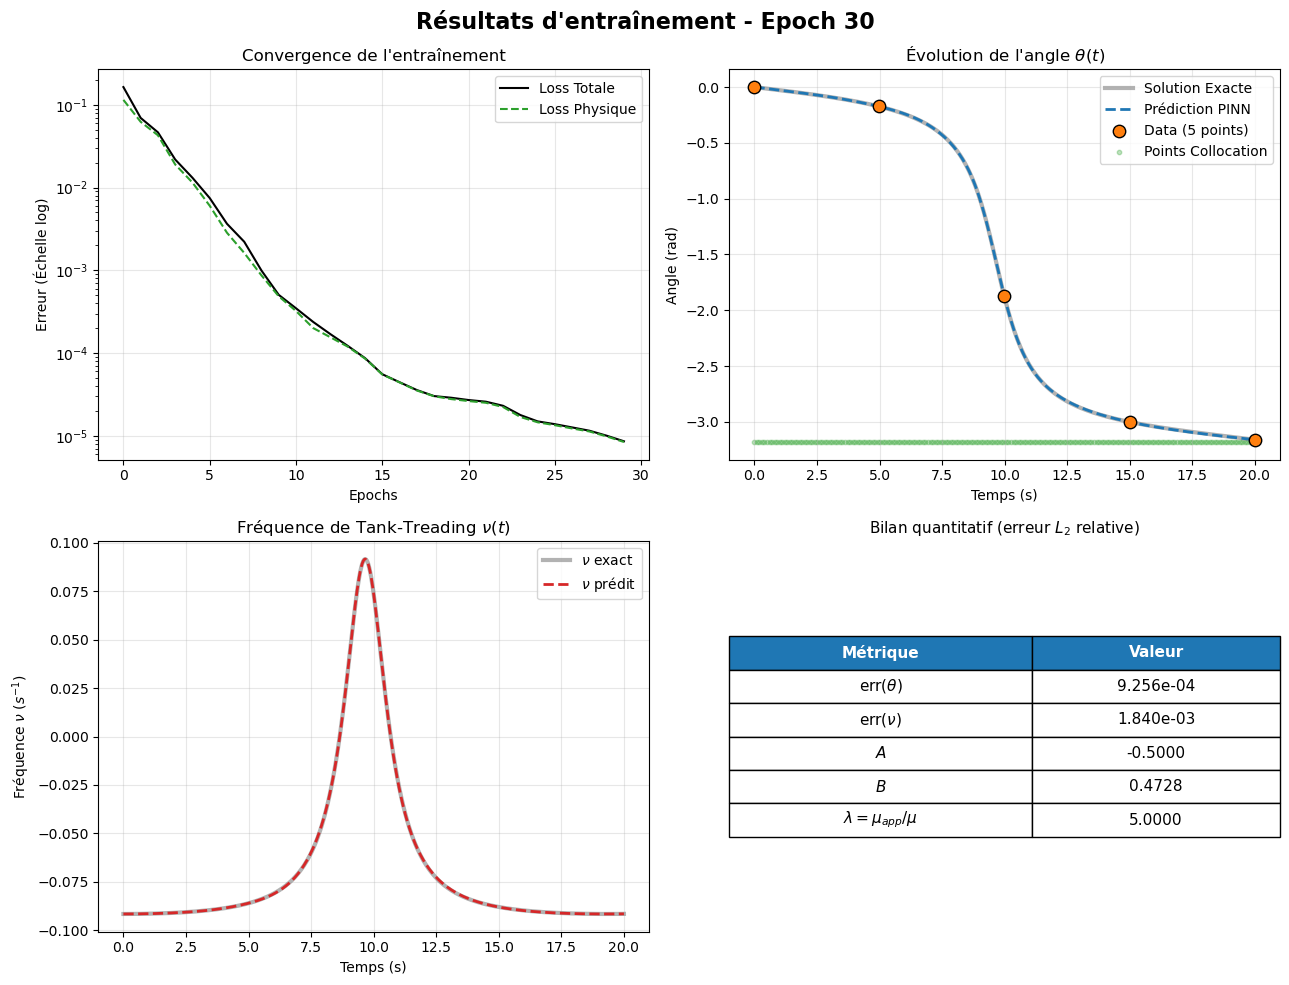

Epoch    40 | Loss Globale: 2.5441e-06 | Loss Phys: 2.5255e-06 | Loss Data: 1.8403e-08
Epoch    50 | Loss Globale: 8.1910e-07 | Loss Phys: 8.1066e-07 | Loss Data: 8.4404e-09
>>> Génération et affichage des graphiques pour l'epoch 50...


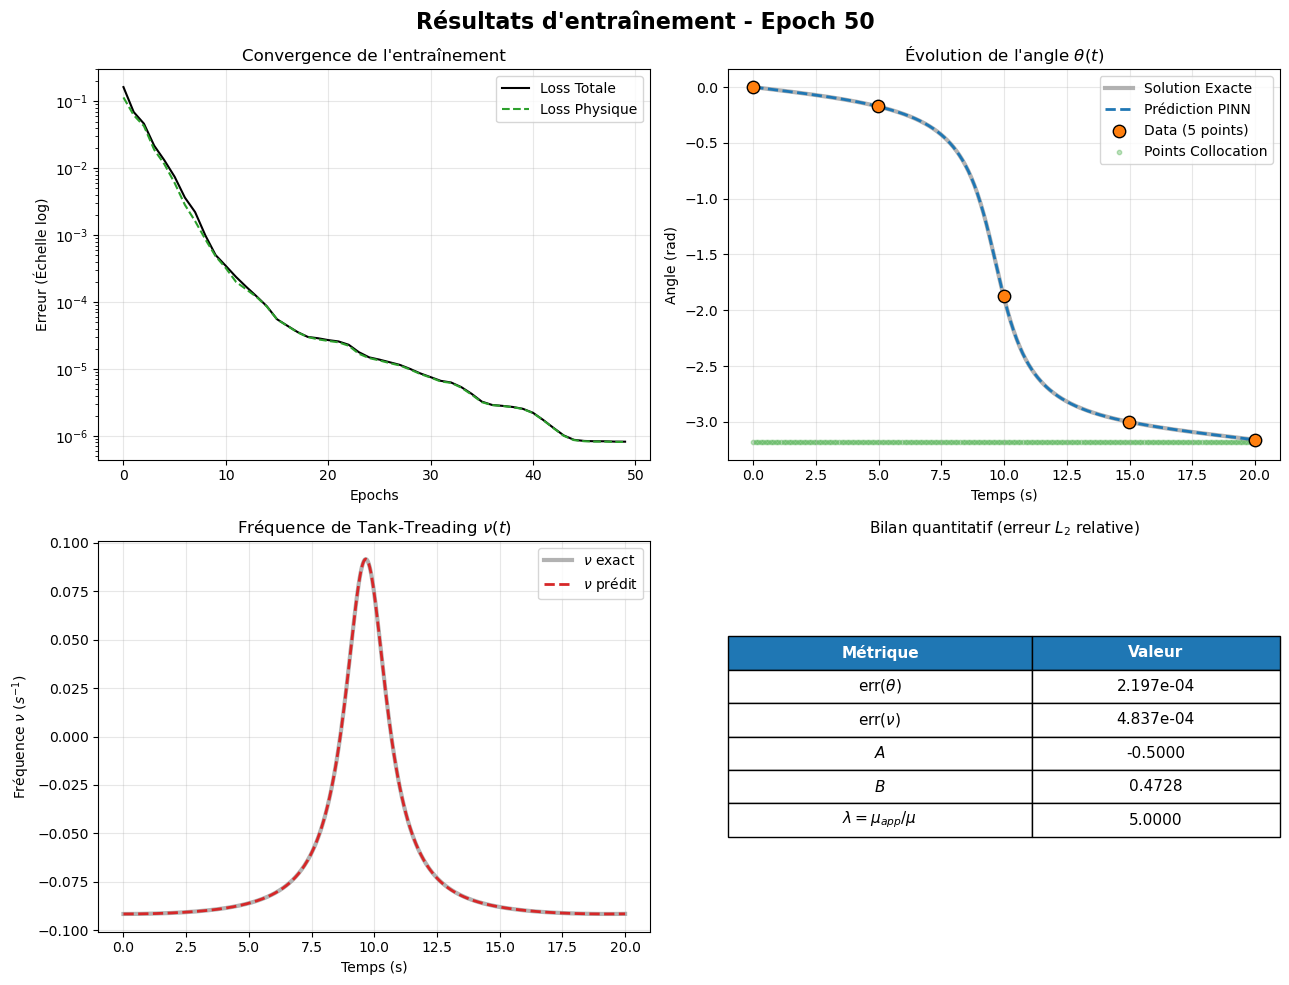

Epoch    60 | Loss Globale: 8.0990e-07 | Loss Phys: 8.0297e-07 | Loss Data: 6.9247e-09
Epoch    70 | Loss Globale: 7.9983e-07 | Loss Phys: 7.9353e-07 | Loss Data: 6.2814e-09
Epoch    80 | Loss Globale: 7.9876e-07 | Loss Phys: 7.9188e-07 | Loss Data: 6.8475e-09
Epoch    90 | Loss Globale: 7.9876e-07 | Loss Phys: 7.9188e-07 | Loss Data: 6.8475e-09
Epoch   100 | Loss Globale: 7.9876e-07 | Loss Phys: 7.9188e-07 | Loss Data: 6.8475e-09
>>> Génération et affichage des graphiques pour l'epoch 100...


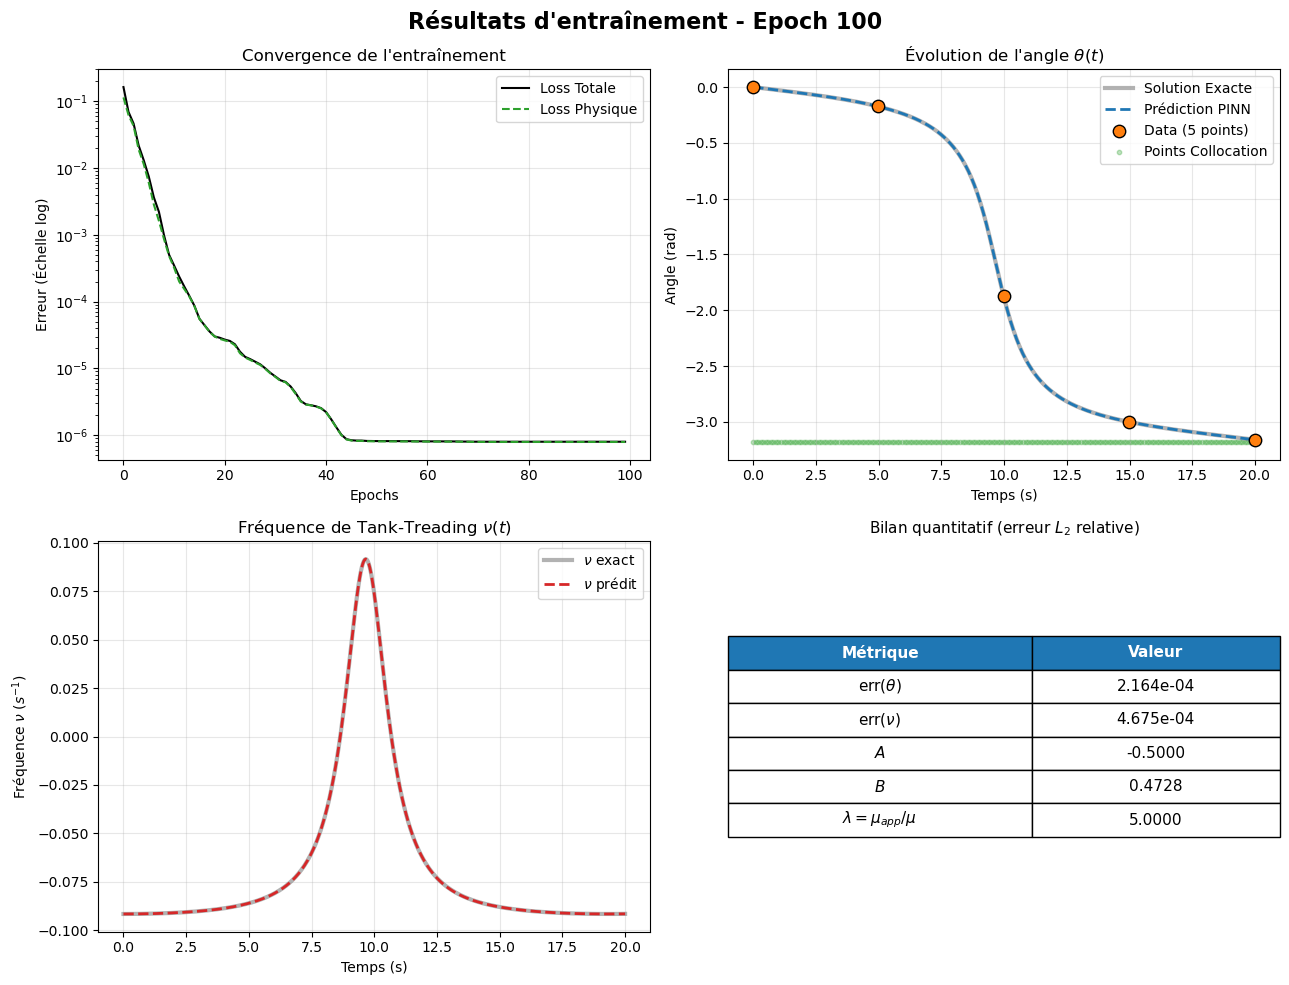

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
KSpur_muapp5.0_lambda5.0            | err_theta = 2.164e-04 | err_nu = 4.675e-04


(0.0002164129643792303, 0.00046753526048458387)

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Reset explicite : ce script travaille en float32, indépendamment de ce qui a
# été exécuté avant dans le même kernel (ex: un script du problème inverse en
# float64, dont le réglage reste actif tant que le kernel tourne).
torch.set_default_dtype(torch.float32)

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics_ks_pur(test_name, theta_pinn, theta_ref, nu_pinn, nu_ref,
                                   filename="metriques_tests.txt"):
    """Version adaptée au modèle KS pur : une seule sortie (theta), pas de omega.
    Calcule les erreurs L2 relatives sur theta et nu, et ajoute une ligne au
    fichier récapitulatif commun à tous les tests."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.0
mu_app = 5.0
theta0_val = 0.0

def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/a0, a2/a0, a3/a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1/r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)

    f1 = (r2 - (1/r2))**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2

    return f1, f2, f3, z1, r2

def calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2):
    A = -0.5 * kappa
    bracket_term = 1 / (f2 - (mu_app / mu) * f1)
    accolade_term = 0.5 + (1 / z1) * f3 * bracket_term
    B = 2 * kappa * accolade_term * (z1 / ((1 / r2) + r2))

    C_visc = f3 * bracket_term
    return A, B, C_visc

f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)
A, B, C_visc = calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2)

print(f"=== Paramètres Physiques Calculés ===")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
if B > -A:
    print("-> Régime : Orientation Stationnaire")
else:
    print("-> Régime : Basculement (Flipping)")

# =====================================================================
# 2. GÉNÉRATION DE LA VÉRITÉ TERRAIN ET DONNÉES (5 POINTS)
# =====================================================================
def exact_solution_theta(t, A, B, theta0=0.0):
    t_1d = t.flatten()
    if B > -A:
        sqrt_term = np.sqrt(B**2 - A**2)
        D = (sqrt_term * np.tan(theta0) + A + B) / (sqrt_term * np.tan(theta0) - A - B)
        exp_term = np.exp(2 * sqrt_term * t_1d)

        fraction_1 = (B + A) / sqrt_term
        fraction_2 = (D * exp_term + 1) / (D * exp_term - 1)
        theta_t = np.arctan(fraction_1 * fraction_2)
        return theta_t.reshape(-1, 1)
    else:
        sqrt_term = np.sqrt(A**2 - B**2)
        phase_init = np.arctan(np.tan(theta0) * sqrt_term / (A + B))
        theta_t = np.arctan(((A + B) / sqrt_term) * np.tan(sqrt_term * t_1d + phase_init))
        theta_t_continue = np.unwrap(2 * theta_t) / 2
        return theta_t_continue.reshape(-1, 1)

t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)
y_exact_np = exact_solution_theta(t_exact_np, A, B, theta0=theta0_val)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
y_exact = torch.tensor(y_exact_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
y_data = y_exact[data_idx].detach()

print(f"Indices des points data sélectionnés : {data_idx}")
print(f"Temps correspondants : {t_data.flatten().tolist()}")

t_ic = torch.tensor([[0.0]], requires_grad=True)

# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()

        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

model = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=20,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []

# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille 2x2 conservée ; le graphique de nu(t) passe en case normale
#     -- au lieu de pleine largeur -- pour libérer une case pour le tableau)
# =====================================================================
def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn = current_model(t_exact).numpy()
        nu_pred = -C_visc * kappa * np.cos(2 * theta_pinn)
        nu_exact = -C_visc * kappa * np.cos(2 * y_exact_np)

    # --- Métriques L2 à l'epoch courante (affichage seulement, pas
    #     d'écriture dans le fichier -> réservée à la métrique finale,
    #     section 6, après la boucle complète) ---
    err_theta = l2_relative_error(theta_pinn, y_exact_np)
    err_nu = l2_relative_error(nu_pred, nu_exact)

    fig = plt.figure(figsize=(13, 10))
    fig.suptitle(f"Résultats d'entraînement - Epoch {current_epoch}", fontsize=16, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
    ax1.set_yscale('log')
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (Échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(t_exact_np, y_exact_np, color="grey", linewidth=3, alpha=0.6, label="Solution Exacte")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), y_data.numpy(), color="tab:orange", s=80, edgecolors='black', zorder=5, label="Data (5 points)")

    colloc_y = np.min(y_exact_np) - 0.02
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")

    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label="$\\nu$ exact")
    ax3.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label="$\\nu$ prédit")
    ax3.set_title("Fréquence de Tank-Treading $\\nu(t)$")
    ax3.set_xlabel("Temps (s)")
    ax3.set_ylabel("Fréquence $\\nu$ ($s^{-1}$)")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # --- Tableau des métriques, case libre (position 4, bas-droite) ---
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$A$",           f"{A:.4f}"],
        [r"$B$",           f"{B:.4f}"],
        [r"$\lambda=\mu_{app}/\mu$", f"{mu_app/mu:.4f}"],
    ]
    tbl = ax4.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.55, 0.45],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax4.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    plt.tight_layout()
    plt.show()
    current_model.train()

# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [30, 50, 100]

print("\n=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===")

for epoch in range(n_epochs):

    loss_tracker = {'total': 0.0, 'phys': 0.0, 'data': 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics,
            grad_outputs=torch.ones_like(theta_pred),
            create_graph=True
        )[0]
        physics_residu = dtheta_dt - (A + B * torch.cos(2 * theta_pred))
        loss_physics = torch.mean(physics_residu**2)

        theta_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val)**2)

        y_data_pred = model(t_data)
        loss_data = torch.mean((y_data_pred - y_data)**2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0

        loss.backward()

        loss_tracker['total'] = loss.item()
        loss_tracker['phys'] = loss_physics.item()
        loss_tracker['data'] = loss_data.item()

        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker['total'])
    loss_phys_hist.append(loss_tracker['phys'])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} | Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final = model(t_exact).numpy()
model.train()

nu_final = -C_visc * kappa * np.cos(2 * theta_final)
nu_ref_final = -C_visc * kappa * np.cos(2 * y_exact_np)

print_and_save_metrics_ks_pur(
    f"KSpur_muapp{mu_app:.1f}_lambda{mu_app/mu:.1f}",
    theta_final, y_exact_np,
    nu_final, nu_ref_final,
)

=== Paramètres Physiques Calculés ===
A = -0.5000
B = 0.5891
-> Régime : Orientation Stationnaire
Indices des points data sélectionnés : [  0 124 249 374 499]
Temps correspondants : [0.0, 4.969939708709717, 9.979959487915039, 14.98997974395752, 20.0]

=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===
Epoch     1 | Loss Globale: 3.9516e-05 | Loss Phys: 2.5457e-05 | Loss Data: 9.1330e-06
Epoch    10 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    20 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    30 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 30...


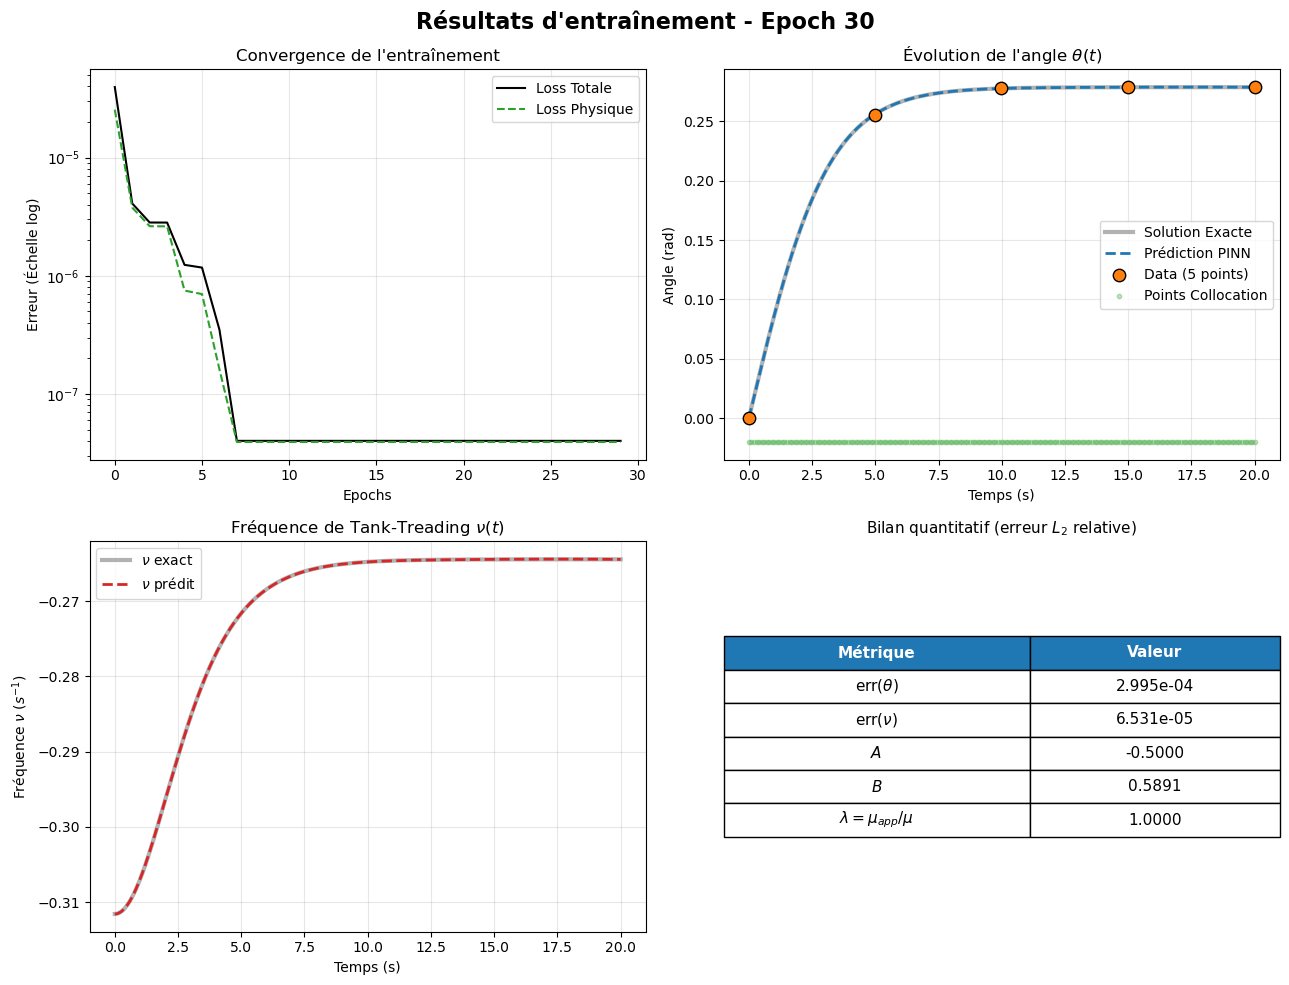

Epoch    40 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    50 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 50...


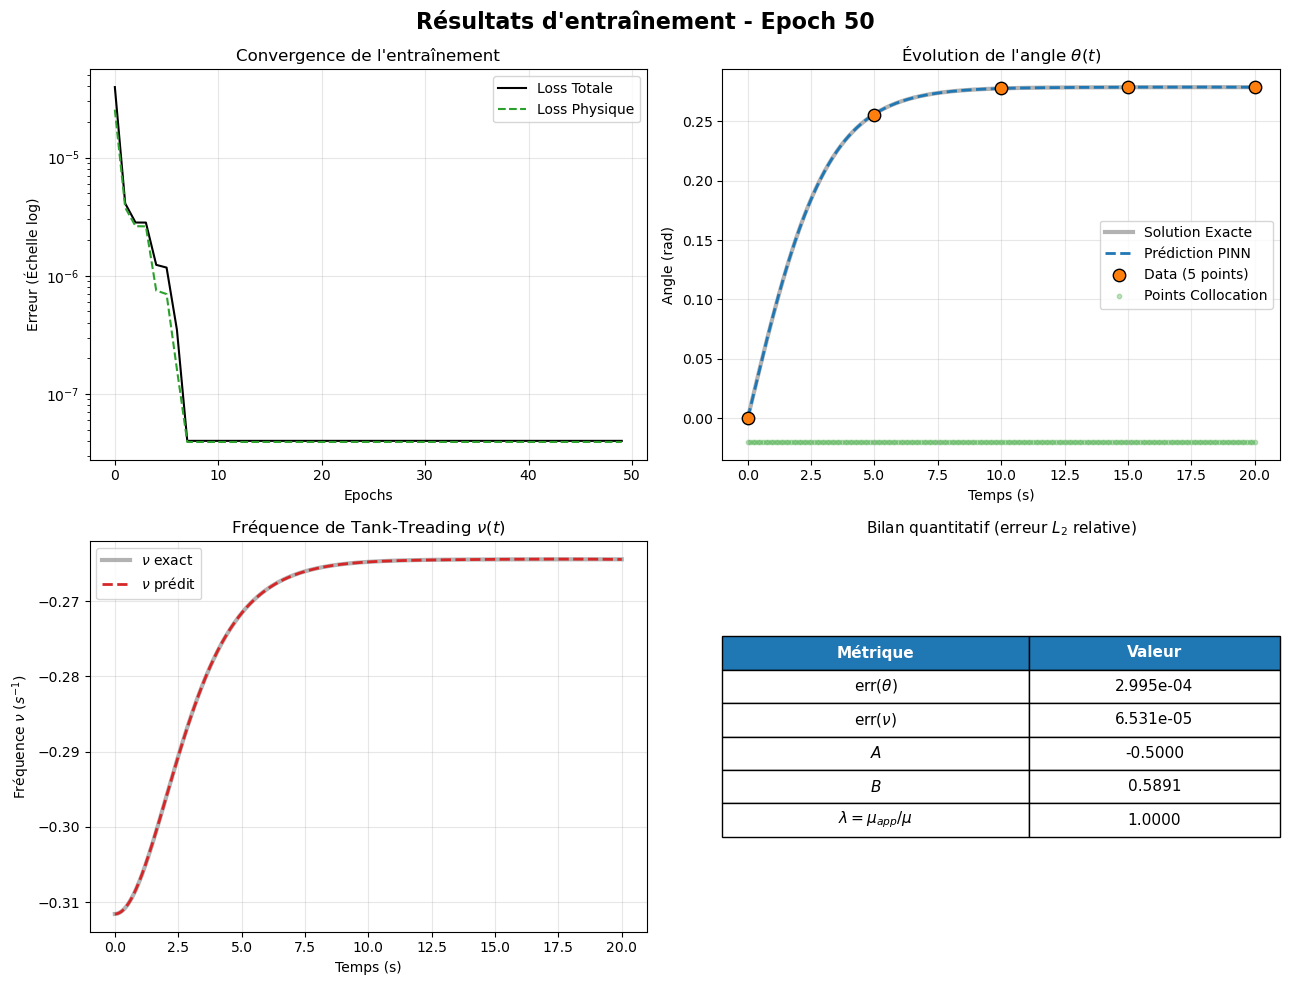

Epoch    60 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    70 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    80 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    90 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch   100 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 100...


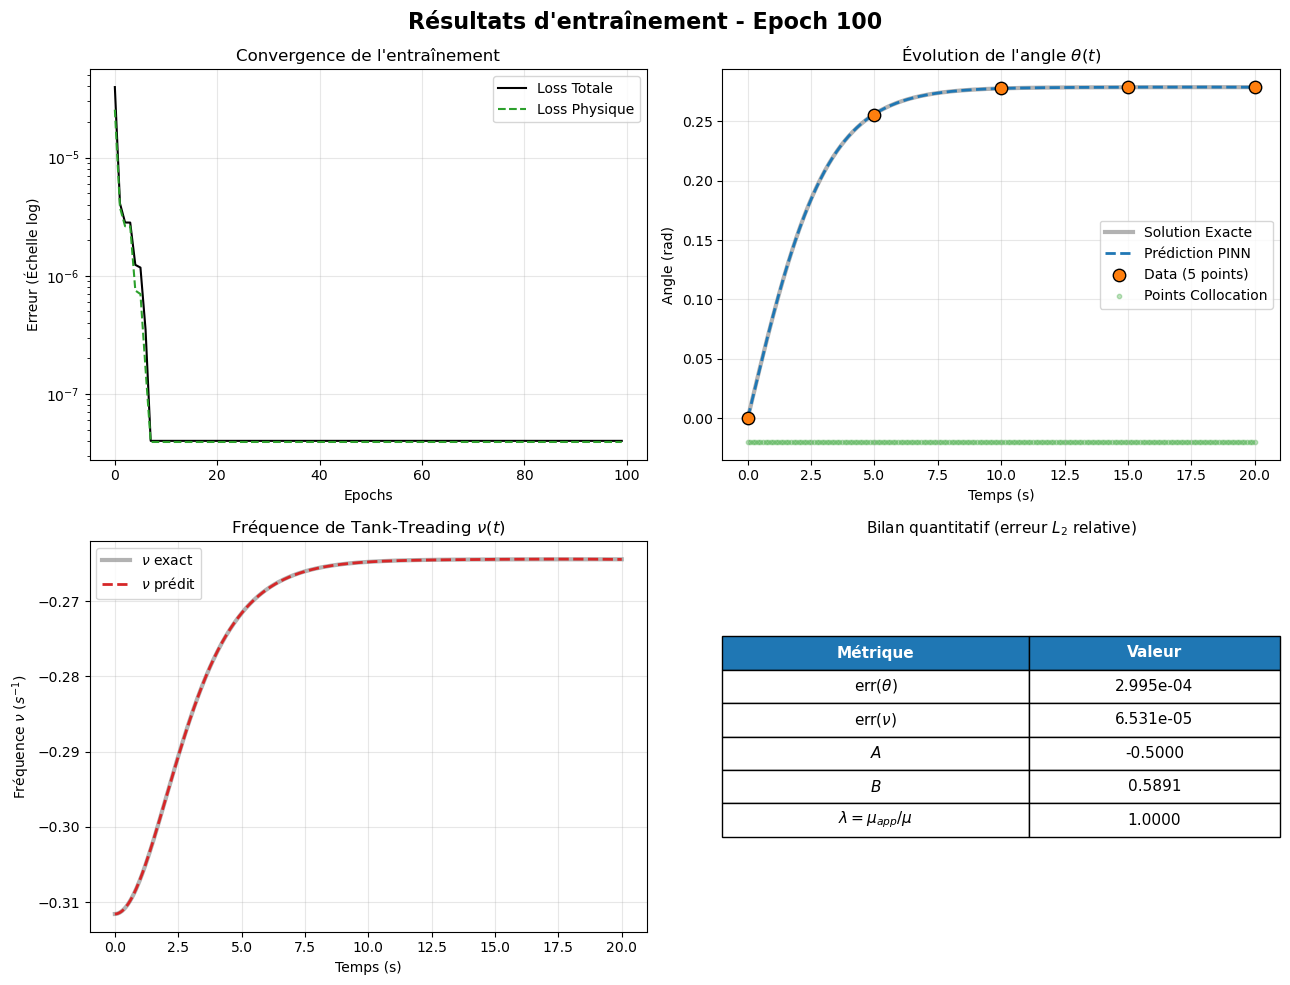

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
KSpur_muapp1.2_lambda1.0            | err_theta = 2.995e-04 | err_nu = 6.531e-05


(0.0002995416184268535, 6.530660854933178e-05)

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Reset explicite : ce script travaille en float32, indépendamment de ce qui a
# été exécuté avant dans le même kernel (ex: un script du problème inverse en
# float64, dont le réglage reste actif tant que le kernel tourne).
torch.set_default_dtype(torch.float32)

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics_ks_pur(test_name, theta_pinn, theta_ref, nu_pinn, nu_ref,
                                   filename="metriques_tests.txt"):
    """Version adaptée au modèle KS pur : une seule sortie (theta), pas de omega.
    Calcule les erreurs L2 relatives sur theta et nu, et ajoute une ligne au
    fichier récapitulatif commun à tous les tests."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.2
mu_app = 1.2
theta0_val = 0.0

def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/a0, a2/a0, a3/a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1/r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)

    f1 = (r2 - (1/r2))**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2

    return f1, f2, f3, z1, r2

def calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2):
    A = -0.5 * kappa
    bracket_term = 1 / (f2 - (mu_app / mu) * f1)
    accolade_term = 0.5 + (1 / z1) * f3 * bracket_term
    B = 2 * kappa * accolade_term * (z1 / ((1 / r2) + r2))

    C_visc = f3 * bracket_term
    return A, B, C_visc

f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)
A, B, C_visc = calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2)

print(f"=== Paramètres Physiques Calculés ===")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
if B > -A:
    print("-> Régime : Orientation Stationnaire")
else:
    print("-> Régime : Basculement (Flipping)")

# =====================================================================
# 2. GÉNÉRATION DE LA VÉRITÉ TERRAIN ET DONNÉES (5 POINTS)
# =====================================================================
def exact_solution_theta(t, A, B, theta0=0.0):
    t_1d = t.flatten()
    if B > -A:
        sqrt_term = np.sqrt(B**2 - A**2)
        D = (sqrt_term * np.tan(theta0) + A + B) / (sqrt_term * np.tan(theta0) - A - B)
        exp_term = np.exp(2 * sqrt_term * t_1d)

        fraction_1 = (B + A) / sqrt_term
        fraction_2 = (D * exp_term + 1) / (D * exp_term - 1)
        theta_t = np.arctan(fraction_1 * fraction_2)
        return theta_t.reshape(-1, 1)
    else:
        sqrt_term = np.sqrt(A**2 - B**2)
        phase_init = np.arctan(np.tan(theta0) * sqrt_term / (A + B))
        theta_t = np.arctan(((A + B) / sqrt_term) * np.tan(sqrt_term * t_1d + phase_init))
        theta_t_continue = np.unwrap(2 * theta_t) / 2
        return theta_t_continue.reshape(-1, 1)

t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)
y_exact_np = exact_solution_theta(t_exact_np, A, B, theta0=theta0_val)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
y_exact = torch.tensor(y_exact_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
y_data = y_exact[data_idx].detach()

print(f"Indices des points data sélectionnés : {data_idx}")
print(f"Temps correspondants : {t_data.flatten().tolist()}")

t_ic = torch.tensor([[0.0]], requires_grad=True)

# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()

        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

model = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=20,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []

# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille 2x2 conservée ; le graphique de nu(t) passe en case normale
#     -- au lieu de pleine largeur -- pour libérer une case pour le tableau)
# =====================================================================
def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn = current_model(t_exact).numpy()
        nu_pred = -C_visc * kappa * np.cos(2 * theta_pinn)
        nu_exact = -C_visc * kappa * np.cos(2 * y_exact_np)

    # --- Métriques L2 à l'epoch courante (affichage seulement, pas
    #     d'écriture dans le fichier -> réservée à la métrique finale,
    #     section 6, après la boucle complète) ---
    err_theta = l2_relative_error(theta_pinn, y_exact_np)
    err_nu = l2_relative_error(nu_pred, nu_exact)

    fig = plt.figure(figsize=(13, 10))
    fig.suptitle(f"Résultats d'entraînement - Epoch {current_epoch}", fontsize=16, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
    ax1.set_yscale('log')
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (Échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(t_exact_np, y_exact_np, color="grey", linewidth=3, alpha=0.6, label="Solution Exacte")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), y_data.numpy(), color="tab:orange", s=80, edgecolors='black', zorder=5, label="Data (5 points)")

    colloc_y = np.min(y_exact_np) - 0.02
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")

    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label="$\\nu$ exact")
    ax3.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label="$\\nu$ prédit")
    ax3.set_title("Fréquence de Tank-Treading $\\nu(t)$")
    ax3.set_xlabel("Temps (s)")
    ax3.set_ylabel("Fréquence $\\nu$ ($s^{-1}$)")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # --- Tableau des métriques, case libre (position 4, bas-droite) ---
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$A$",           f"{A:.4f}"],
        [r"$B$",           f"{B:.4f}"],
        [r"$\lambda=\mu_{app}/\mu$", f"{mu_app/mu:.4f}"],
    ]
    tbl = ax4.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.55, 0.45],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax4.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    plt.tight_layout()
    plt.show()
    current_model.train()

# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [30, 50, 100]

print("\n=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===")

for epoch in range(n_epochs):

    loss_tracker = {'total': 0.0, 'phys': 0.0, 'data': 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics,
            grad_outputs=torch.ones_like(theta_pred),
            create_graph=True
        )[0]
        physics_residu = dtheta_dt - (A + B * torch.cos(2 * theta_pred))
        loss_physics = torch.mean(physics_residu**2)

        theta_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val)**2)

        y_data_pred = model(t_data)
        loss_data = torch.mean((y_data_pred - y_data)**2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0

        loss.backward()

        loss_tracker['total'] = loss.item()
        loss_tracker['phys'] = loss_physics.item()
        loss_tracker['data'] = loss_data.item()

        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker['total'])
    loss_phys_hist.append(loss_tracker['phys'])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} | Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final = model(t_exact).numpy()
model.train()

nu_final = -C_visc * kappa * np.cos(2 * theta_final)
nu_ref_final = -C_visc * kappa * np.cos(2 * y_exact_np)

print_and_save_metrics_ks_pur(
    f"KSpur_muapp{mu_app:.1f}_lambda{mu_app/mu:.1f}",
    theta_final, y_exact_np,
    nu_final, nu_ref_final,
)

=== Paramètres Physiques Calculés ===
A = -0.5000
B = 0.5891
-> Régime : Orientation Stationnaire
Indices des points data sélectionnés : [  0 124 249 374 499]
Temps correspondants : [0.0, 4.969939708709717, 9.979959487915039, 14.98997974395752, 20.0]

=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===
Epoch     1 | Loss Globale: 3.9516e-05 | Loss Phys: 2.5457e-05 | Loss Data: 9.1330e-06
Epoch    10 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    20 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    30 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 30...


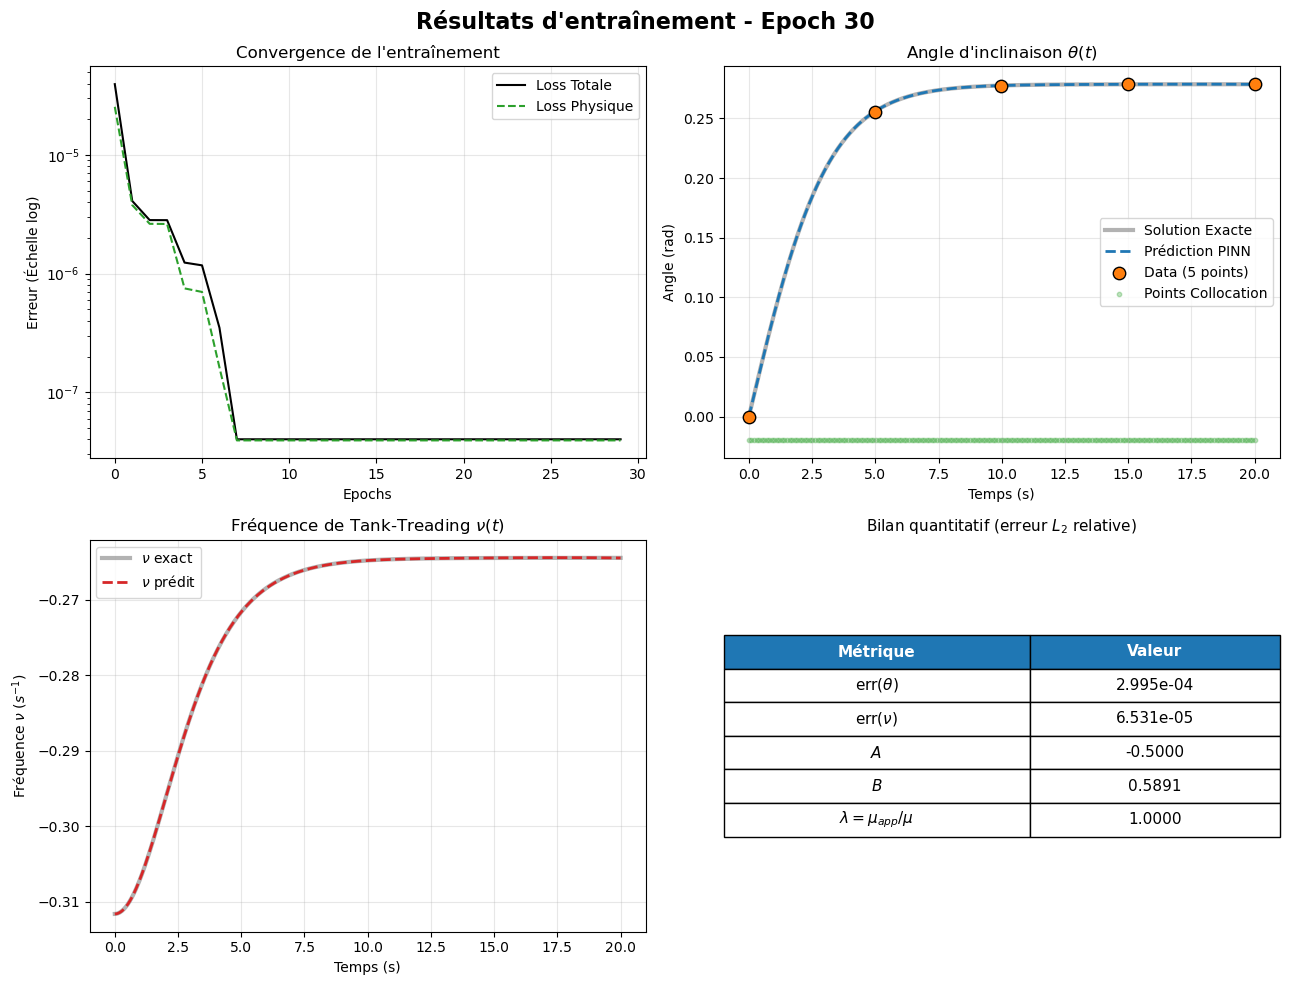

Epoch    40 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    50 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 50...


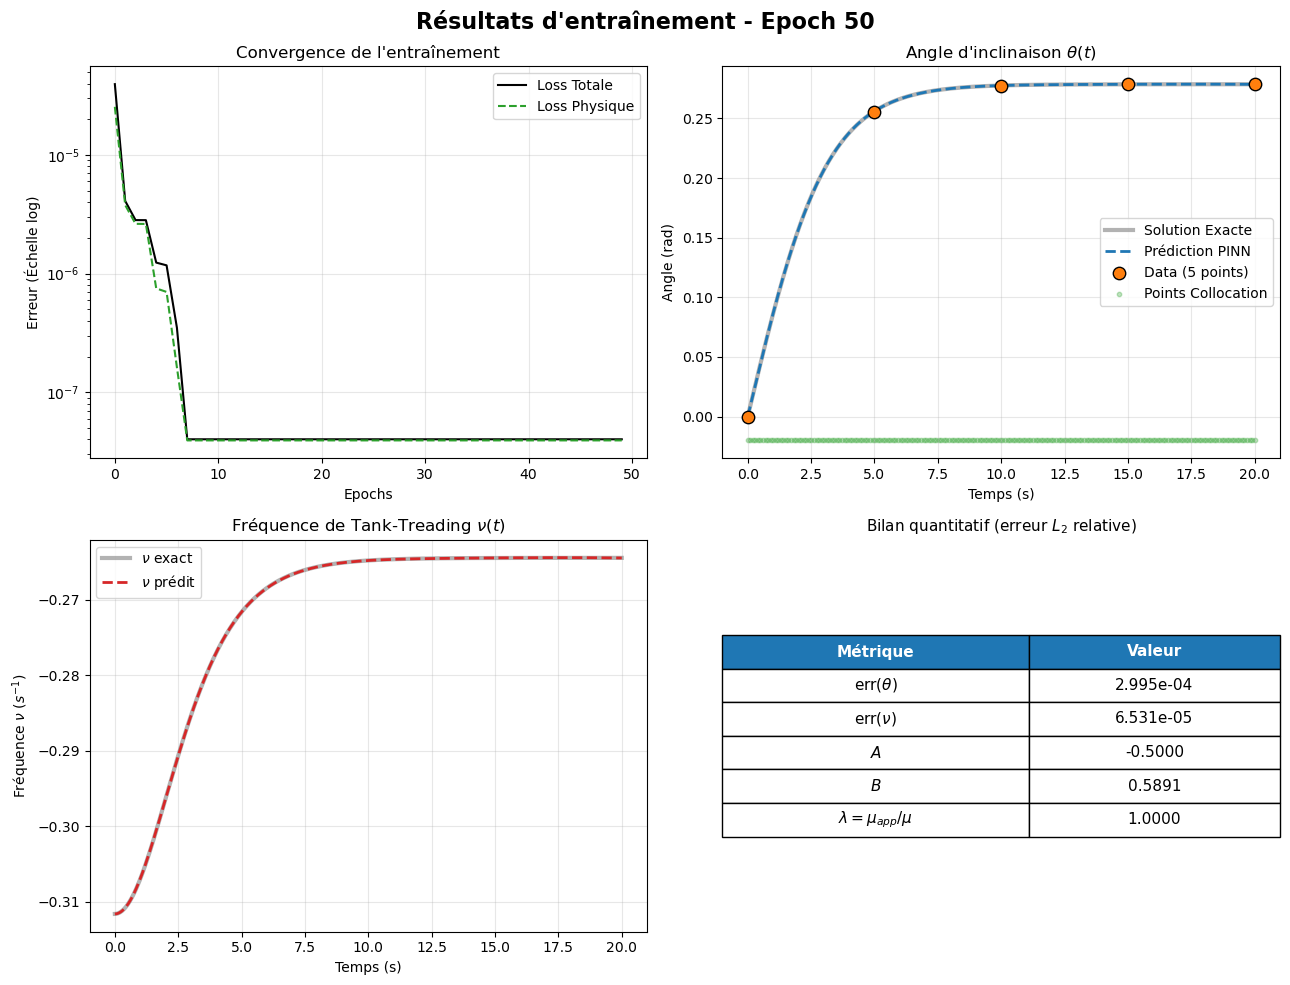

Epoch    60 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    70 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    80 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch    90 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
Epoch   100 | Loss Globale: 4.0131e-08 | Loss Phys: 3.9264e-08 | Loss Data: 8.4620e-10
>>> Génération et affichage des graphiques pour l'epoch 100...


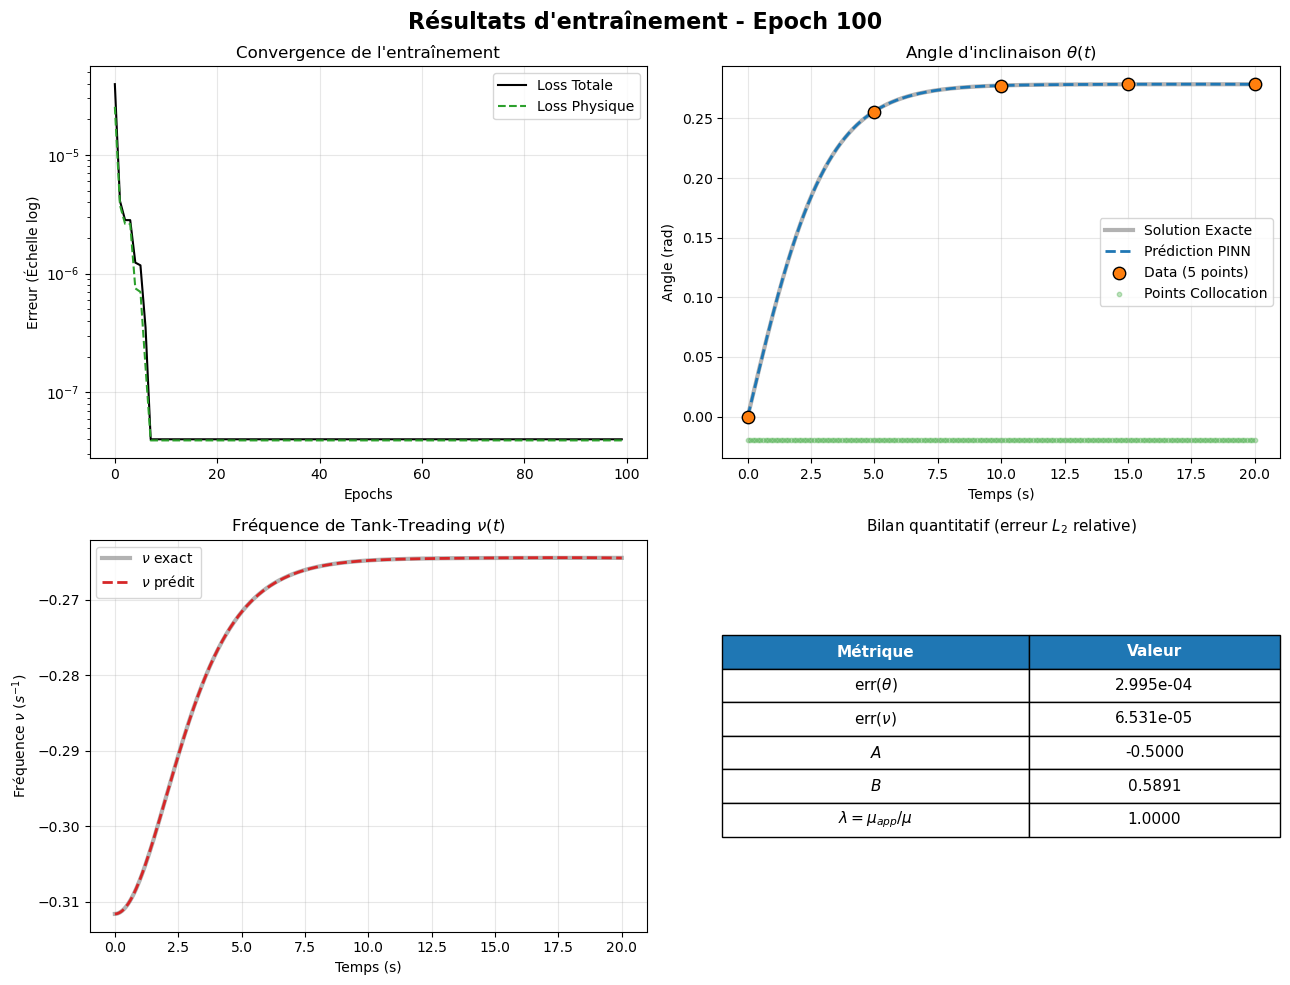

Entraînement terminé.


=== Métriques quantitatives (erreur L2 relative) ===
KSpur_muapp1.2_lambda1.0            | err_theta = 2.995e-04 | err_nu = 6.531e-05


(0.0002995416184268535, 6.530660854933178e-05)

In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics_ks_pur(test_name, theta_pinn, theta_ref, nu_pinn, nu_ref,
                                   filename="metriques_tests.txt"):
    """Version adaptée au modèle KS pur : une seule sortie (theta), pas de omega.
    Calcule les erreurs L2 relatives sur theta et nu, et ajoute une ligne au
    fichier récapitulatif commun à tous les tests."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_nu = {err_nu:.3e}")

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.2
mu_app = 1.2
theta0_val = 0.0

def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/a0, a2/a0, a3/a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1/r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)

    f1 = (r2 - (1/r2))**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2

    return f1, f2, f3, z1, r2

def calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2):
    A = -0.5 * kappa
    bracket_term = 1 / (f2 - (mu_app / mu) * f1)
    accolade_term = 0.5 + (1 / z1) * f3 * bracket_term
    B = 2 * kappa * accolade_term * (z1 / ((1 / r2) + r2))

    C_visc = f3 * bracket_term
    return A, B, C_visc

f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)
A, B, C_visc = calculate_physics_constants(kappa, mu, mu_app, f1, f2, f3, z1, r2)

print(f"=== Paramètres Physiques Calculés ===")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
if B > -A:
    print("-> Régime : Orientation Stationnaire")
else:
    print("-> Régime : Basculement (Flipping)")

# =====================================================================
# 2. GÉNÉRATION DE LA VÉRITÉ TERRAIN ET DONNÉES (5 POINTS)
# =====================================================================
def exact_solution_theta(t, A, B, theta0=0.0):
    t_1d = t.flatten()
    if B > -A:
        sqrt_term = np.sqrt(B**2 - A**2)
        D = (sqrt_term * np.tan(theta0) + A + B) / (sqrt_term * np.tan(theta0) - A - B)
        exp_term = np.exp(2 * sqrt_term * t_1d)

        fraction_1 = (B + A) / sqrt_term
        fraction_2 = (D * exp_term + 1) / (D * exp_term - 1)
        theta_t = np.arctan(fraction_1 * fraction_2)
        return theta_t.reshape(-1, 1)
    else:
        sqrt_term = np.sqrt(A**2 - B**2)
        phase_init = np.arctan(np.tan(theta0) * sqrt_term / (A + B))
        theta_t = np.arctan(((A + B) / sqrt_term) * np.tan(sqrt_term * t_1d + phase_init))
        theta_t_continue = np.unwrap(2 * theta_t) / 2
        return theta_t_continue.reshape(-1, 1)

t_min, t_max = 0.0, 20
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)
y_exact_np = exact_solution_theta(t_exact_np, A, B, theta0=theta0_val)

t_exact = torch.tensor(t_exact_np, dtype=torch.float32)
y_exact = torch.tensor(y_exact_np, dtype=torch.float32)

data_idx = np.linspace(0, len(t_exact_np) - 1, 5).astype(int)
t_data = t_exact[data_idx].detach()
y_data = y_exact[data_idx].detach()

print(f"Indices des points data sélectionnés : {data_idx}")
print(f"Temps correspondants : {t_data.flatten().tolist()}")

t_ic = torch.tensor([[0.0]], requires_grad=True)

# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET DE L'OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()

        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

model = FCN(N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3)

optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=20,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde).view(-1, 1).requires_grad_(True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []

# =====================================================================
# 4. FONCTION D'AFFICHAGE EN COURS D'ENTRAÎNEMENT
#    (grille 2x2 conservée ; le graphique de nu(t) passe en case normale
#     -- au lieu de pleine largeur -- pour libérer une case pour le tableau)
# =====================================================================
def plot_current_state(current_epoch, current_model):
    current_model.eval()
    with torch.no_grad():
        theta_pinn = current_model(t_exact).numpy()
        nu_pred = -C_visc * kappa * np.cos(2 * theta_pinn)
        nu_exact = -C_visc * kappa * np.cos(2 * y_exact_np)

    # --- Métriques L2 à l'epoch courante (affichage seulement, pas
    #     d'écriture dans le fichier -> réservée à la métrique finale,
    #     section 6, après la boucle complète) ---
    err_theta = l2_relative_error(theta_pinn, y_exact_np)
    err_nu = l2_relative_error(nu_pred, nu_exact)

    fig = plt.figure(figsize=(13, 10))
    fig.suptitle(f"Résultats d'entraînement - Epoch {current_epoch}", fontsize=16, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
    ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
    ax1.set_yscale('log')
    ax1.set_title("Convergence de l'entraînement")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Erreur (Échelle log)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(t_exact_np, y_exact_np, color="grey", linewidth=3, alpha=0.6, label="Solution Exacte")
    ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="Prédiction PINN")
    ax2.scatter(t_data.numpy(), y_data.numpy(), color="tab:orange", s=80, edgecolors='black', zorder=5, label="Data (5 points)")

    colloc_y = np.min(y_exact_np) - 0.02
    ax2.scatter(t_physics.detach().numpy(), colloc_y * np.ones_like(t_physics.detach().numpy()),
                color="tab:green", s=10, alpha=0.3, label="Points Collocation")

    ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
    ax2.set_xlabel("Temps (s)")
    ax2.set_ylabel("Angle (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label="$\\nu$ exact")
    ax3.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label="$\\nu$ prédit")
    ax3.set_title("Fréquence de Tank-Treading $\\nu(t)$")
    ax3.set_xlabel("Temps (s)")
    ax3.set_ylabel("Fréquence $\\nu$ ($s^{-1}$)")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    # --- Tableau des métriques, case libre (position 4, bas-droite) ---
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis("off")
    table_data = [
        [r"err($\theta$)", f"{err_theta:.3e}"],
        [r"err($\nu$)",    f"{err_nu:.3e}"],
        [r"$A$",           f"{A:.4f}"],
        [r"$B$",           f"{B:.4f}"],
        [r"$\lambda=\mu_{app}/\mu$", f"{mu_app/mu:.4f}"],
    ]
    tbl = ax4.table(
        cellText=table_data,
        colLabels=["Métrique", "Valeur"],
        cellLoc="center",
        loc="center",
        colWidths=[0.55, 0.45],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight="bold", color="white")
            cell.set_facecolor("tab:blue")
    ax4.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)

    plt.tight_layout()
    plt.show()
    current_model.train()

# =====================================================================
# 5. BOUCLE D'ENTRAÎNEMENT L-BFGS
# =====================================================================
n_epochs = 100
epochs_to_plot = [30, 50, 100]

print("\n=== Début de l'entraînement PINN (Guidé par 5 points via L-BFGS) ===")

for epoch in range(n_epochs):

    loss_tracker = {'total': 0.0, 'phys': 0.0, 'data': 0.0}

    def closure():
        optimizer.zero_grad()

        theta_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(
            theta_pred, t_physics,
            grad_outputs=torch.ones_like(theta_pred),
            create_graph=True
        )[0]
        physics_residu = dtheta_dt - (A + B * torch.cos(2 * theta_pred))
        loss_physics = torch.mean(physics_residu**2)

        theta_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val)**2)

        y_data_pred = model(t_data)
        loss_data = torch.mean((y_data_pred - y_data)**2)

        w_phys = 1
        loss = loss_data + w_phys * loss_physics + loss_x0

        loss.backward()

        loss_tracker['total'] = loss.item()
        loss_tracker['phys'] = loss_physics.item()
        loss_tracker['data'] = loss_data.item()

        return loss

    optimizer.step(closure)

    loss_total_hist.append(loss_tracker['total'])
    loss_phys_hist.append(loss_tracker['phys'])
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Loss Globale: {loss_tracker['total']:.4e} | Loss Phys: {loss_tracker['phys']:.4e} | Loss Data: {loss_tracker['data']:.4e}")

    if (epoch + 1) in epochs_to_plot:
        print(f">>> Génération et affichage des graphiques pour l'epoch {epoch+1}...")
        plot_current_state(epoch + 1, model)

print("Entraînement terminé.\n")


# =====================================================================
# 6. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, ici, après la boucle)
# =====================================================================
model.eval()
with torch.no_grad():
    theta_final = model(t_exact).numpy()
model.train()

nu_final = -C_visc * kappa * np.cos(2 * theta_final)
nu_ref_final = -C_visc * kappa * np.cos(2 * y_exact_np)

print_and_save_metrics_ks_pur(
    f"KSpur_muapp{mu_app:.1f}_lambda{mu_app/mu:.1f}",
    theta_final, y_exact_np,
    nu_final, nu_ref_final,
)

Indices sélectionnés : [  0 124 249 374 499]
Temps t_data sélectionnés : [0.0, 4.969939879759519, 9.97995991983968, 14.98997995991984, 20.0]

=== Début Problème Inverse (L-BFGS Uniquement) ===
Objectif : Retrouver mu_app = 5.0
Supposition initiale : mu_app = 1.0000

L-BFGS Epoch    1 | Loss: 6.93e-01 | mu_app = 1.0102
L-BFGS Epoch   10 | Loss: 2.39e-03 | mu_app = 2.7714
L-BFGS Epoch   20 | Loss: 4.46e-04 | mu_app = 3.2773
L-BFGS Epoch   30 | Loss: 8.33e-05 | mu_app = 4.3035
L-BFGS Epoch   40 | Loss: 2.90e-05 | mu_app = 4.6207
L-BFGS Epoch   50 | Loss: 1.40e-05 | mu_app = 4.8965
L-BFGS Epoch   60 | Loss: 6.26e-06 | mu_app = 4.9633
L-BFGS Epoch   70 | Loss: 5.18e-06 | mu_app = 4.9948
L-BFGS Epoch   80 | Loss: 5.18e-06 | mu_app = 4.9948
L-BFGS Epoch   90 | Loss: 5.18e-06 | mu_app = 4.9948
L-BFGS Epoch  100 | Loss: 5.18e-06 | mu_app = 4.9948

Entraînement terminé. Valeur trouvée : mu_app = 4.9948 (Vraie : 5.0)

=== Métriques quantitatives (erreur L2 relative) ===
KSpurInverse_mu5to5       

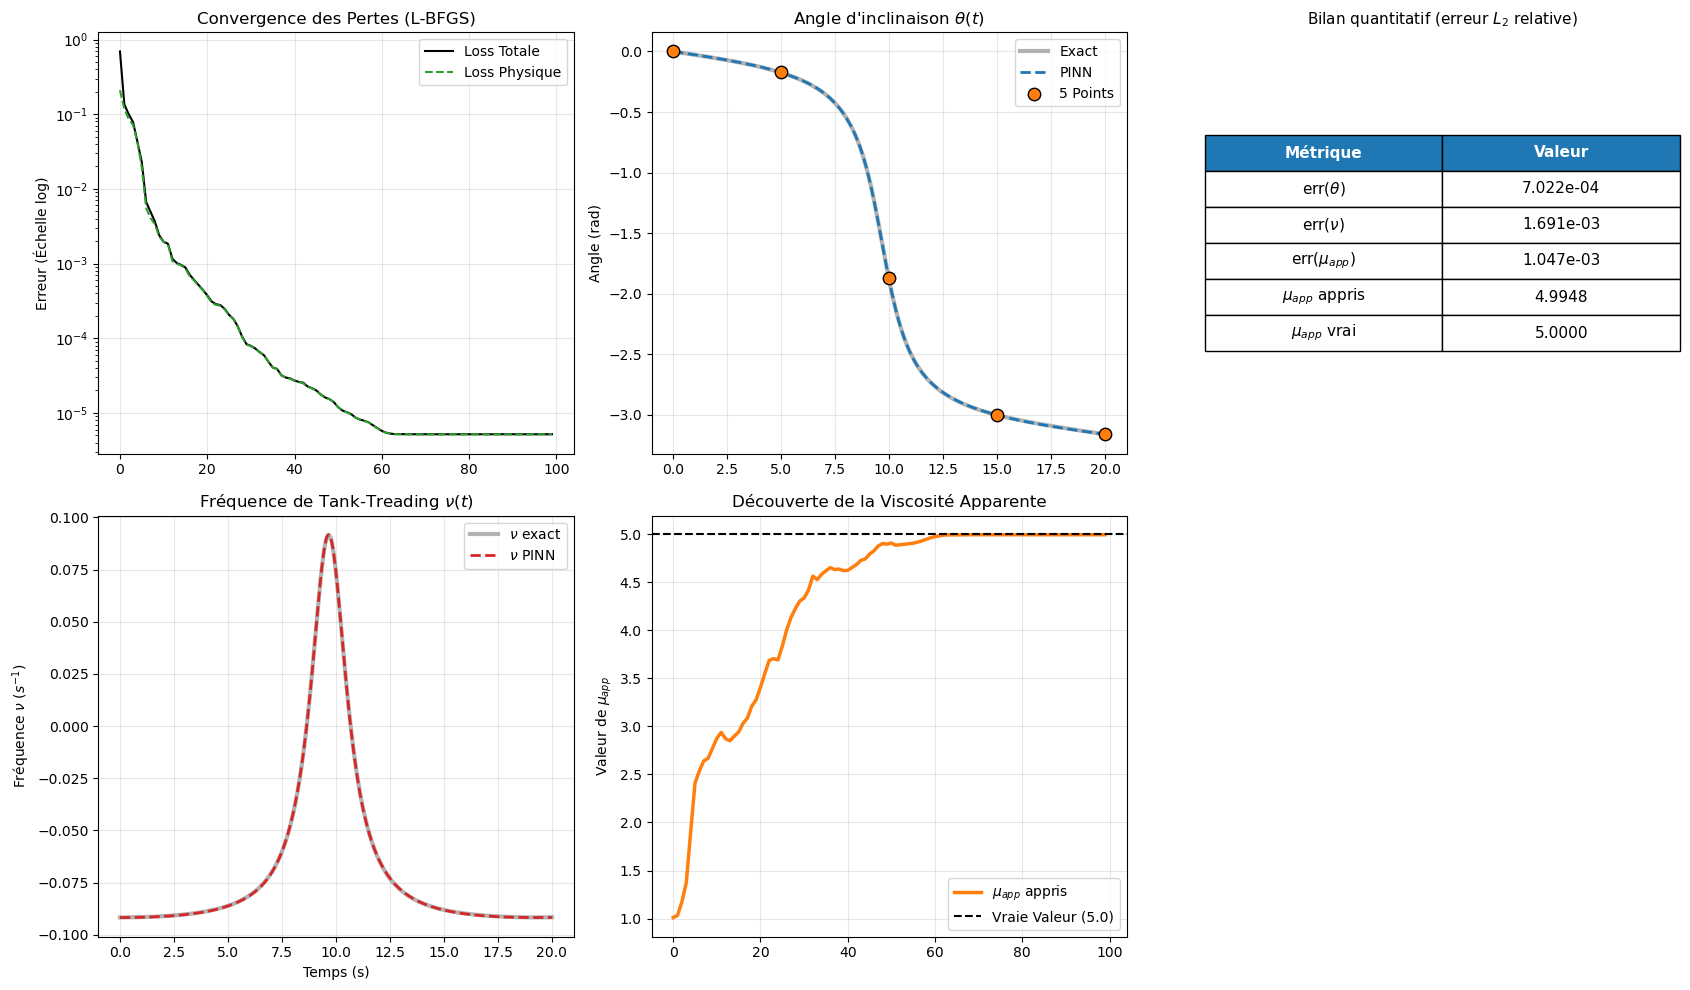

In [20]:
# =====================================================================
# ENTRAÎNEMENT PINN - PROBLÈME INVERSE (DÉCOUVERTE DE PARAMÈTRE)
# =====================================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Passage obligatoire en double précision pour L-BFGS ---
torch.set_default_dtype(torch.float64)
# -----------------------------------------------------------

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics_ks_pur(test_name, theta_pinn, theta_ref, nu_pinn, nu_ref,
                                   mu_app_learned=None, mu_app_true=None,
                                   filename="metriques_tests.txt"):
    """Version KS pur (1 seule sortie theta, pas de omega). Calcule les erreurs
    L2 relatives sur theta et nu, + l'erreur relative sur mu_app si fournie
    (cas du problème inverse), et ajoute une ligne au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_nu = {err_nu:.3e}")

    if mu_app_learned is not None and mu_app_true is not None:
        err_mu_app = abs(mu_app_learned - mu_app_true) / abs(mu_app_true)
        line += f" | err_mu_app = {err_mu_app:.3e} (appris={mu_app_learned:.4f}, vrai={mu_app_true:.4f})"

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 1.0
theta0_val = 0.0

# La "Vraie" viscosité cachée (utilisée UNIQUEMENT pour générer les 5 points)
mu_app_TRUE = 5.0

# --- Le paramètre apprenable ---
mu_app_guess = torch.nn.Parameter(torch.tensor([1.0], dtype=torch.float64))

def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/a0, a2/a0, a3/a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1/r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)

    f1 = (r2 - (1/r2))**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2

f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

def calculate_physics_tensor(kappa, mu, mu_app_tensor, f1, f2, f3, z1, r2):
    A = -0.5 * kappa
    bracket_term = 1 / (f2 - (mu_app_tensor / mu) * f1)
    accolade_term = 0.5 + (1 / z1) * f3 * bracket_term
    B = 2 * kappa * accolade_term * (z1 / ((1 / r2) + r2))
    C_visc = f3 * bracket_term
    return A, B, C_visc

A_true = -0.5 * kappa
bracket_term_true = 1 / (f2 - (mu_app_TRUE / mu) * f1)
accolade_term_true = 0.5 + (1 / z1) * f3 * bracket_term_true
B_true = 2 * kappa * accolade_term_true * (z1 / ((1 / r2) + r2))
C_visc_true = f3 * bracket_term_true

# =====================================================================
# 2. GÉNÉRATION DE LA VÉRITÉ TERRAIN ET DES 5 POINTS
# =====================================================================
def exact_solution_theta(t, A, B, theta0=0.0):
    t_1d = t.flatten()
    if B > -A:
        sqrt_term = np.sqrt(B**2 - A**2)
        D = (sqrt_term * np.tan(theta0) + A + B) / (sqrt_term * np.tan(theta0) - A - B)
        exp_term = np.exp(2 * sqrt_term * t_1d)
        fraction_1 = (B + A) / sqrt_term
        fraction_2 = (D * exp_term + 1) / (D * exp_term - 1)
        theta_t = np.arctan(fraction_1 * fraction_2)
        return theta_t.reshape(-1, 1)
    else:
        sqrt_term = np.sqrt(A**2 - B**2)
        phase_init = np.arctan(np.tan(theta0) * sqrt_term / (A + B))
        theta_t = np.arctan(((A + B) / sqrt_term) * np.tan(sqrt_term * t_1d + phase_init))
        theta_t_continue = np.unwrap(2 * theta_t) / 2
        return theta_t_continue.reshape(-1, 1)

t_min, t_max = 0.0, 20.0
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)
y_exact_np = exact_solution_theta(t_exact_np, A_true, B_true, theta0=theta0_val)

t_exact = torch.tensor(t_exact_np, dtype=torch.float64)
y_exact = torch.tensor(y_exact_np, dtype=torch.float64)

N_total = len(t_exact)
indices_5_points = np.linspace(0, N_total - 1, 5).astype(int)

t_data = t_exact[indices_5_points].detach()
y_data = y_exact[indices_5_points].detach()

print(f"Indices sélectionnés : {indices_5_points}")
print(f"Temps t_data sélectionnés : {t_data.flatten().tolist()}")

# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

model = FCN()

optimizer_lbfgs = torch.optim.LBFGS(
    list(model.parameters()) + [mu_app_guess],
    lr=0.1,
    max_iter=20,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde, dtype=torch.float64).view(-1, 1).requires_grad_(True)
t_ic = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []
mu_app_hist = []

# =====================================================================
# 4. BOUCLE D'ENTRAÎNEMENT L-BFGS PURE (PROBLÈME INVERSE)
# =====================================================================
print(f"\n=== Début Problème Inverse (L-BFGS Uniquement) ===")
print(f"Objectif : Retrouver mu_app = {mu_app_TRUE}")
print(f"Supposition initiale : mu_app = {mu_app_guess.item():.4f}\n")

epochs_lbfgs = 100
w_phys_final = 1.0

for epoch in range(epochs_lbfgs):
    loss_tracker = {'total': 0.0, 'phys': 0.0}

    def closure():
        optimizer_lbfgs.zero_grad()

        A_dyn, B_dyn, _ = calculate_physics_tensor(kappa, mu, mu_app_guess, f1, f2, f3, z1, r2)

        theta_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred), create_graph=True)[0]
        physics_residu = dtheta_dt - (A_dyn + B_dyn * torch.cos(2 * theta_pred))
        loss_physics = torch.mean(physics_residu**2)

        theta_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val)**2)

        y_data_pred = model(t_data)
        loss_data = torch.mean((y_data_pred - y_data)**2)

        loss = 3*loss_data + w_phys_final * loss_physics + loss_x0
        loss.backward()

        loss_tracker['total'] = loss.item()
        loss_tracker['phys'] = loss_physics.item()
        return loss

    optimizer_lbfgs.step(closure)

    loss_total_hist.append(loss_tracker['total'])
    loss_phys_hist.append(loss_tracker['phys'])
    mu_app_hist.append(mu_app_guess.item())
    epoch_hist.append(epoch)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"L-BFGS Epoch {epoch+1:4d} | Loss: {loss_tracker['total']:.2e} | mu_app = {mu_app_guess.item():.4f}")

print(f"\nEntraînement terminé. Valeur trouvée : mu_app = {mu_app_guess.item():.4f} (Vraie : {mu_app_TRUE})")

# =====================================================================
# 5. RÉSULTATS, POST-TRAITEMENT
# =====================================================================
model.eval()
with torch.no_grad():
    theta_pinn = model(t_exact).numpy()

    _, _, C_visc_pred = calculate_physics_tensor(kappa, mu, mu_app_guess, f1, f2, f3, z1, r2)
    nu_pred = -C_visc_pred.item() * kappa * np.cos(2 * theta_pinn)
    nu_exact = -C_visc_true * kappa * np.cos(2 * y_exact_np)
model.train()


# =====================================================================
# 5bis. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, juste ici)
# =====================================================================
err_theta, err_nu = print_and_save_metrics_ks_pur(
    f"KSpurInverse_mu{mu_app_guess.item():.0f}to{mu_app_TRUE:.0f}",
    theta_pinn, y_exact_np,
    nu_pred, nu_exact,
    mu_app_learned=mu_app_guess.item(),
    mu_app_true=mu_app_TRUE,
)

mu_app_learned_val = mu_app_guess.item()
err_mu_app = abs(mu_app_learned_val - mu_app_TRUE) / abs(mu_app_TRUE)


# =====================================================================
# 6. AFFICHAGE (grille passée de 2x2 à 2x3 pour ajouter le tableau
#    de métriques dans une case dédiée, sans toucher aux 4 graphiques)
# =====================================================================
fig = plt.figure(figsize=(17, 10))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
ax1.set_yscale('log')
ax1.set_ylabel("Erreur (Échelle log)")
ax1.set_title("Convergence des Pertes (L-BFGS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(2, 3, 2)
ax2.plot(t_exact_np, y_exact_np, color="grey", linewidth=3, alpha=0.6, label="Exact")
ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="PINN")
ax2.scatter(t_data.numpy(), y_data.numpy(), color="tab:orange", s=80, edgecolors='k', zorder=5, label="5 Points")
ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
ax2.set_ylabel("Angle (rad)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Tableau des métriques, case libre (position 3, haut-droite) ---
ax3 = plt.subplot(2, 3, 3)
ax3.axis("off")
table_data = [
    [r"err($\theta$)",       f"{err_theta:.3e}"],
    [r"err($\nu$)",          f"{err_nu:.3e}"],
    [r"err($\mu_{app}$)",    f"{err_mu_app:.3e}"],
    [r"$\mu_{app}$ appris",  f"{mu_app_learned_val:.4f}"],
    [r"$\mu_{app}$ vrai",    f"{mu_app_TRUE:.4f}"],
]
tbl = ax3.table(
    cellText=table_data,
    colLabels=["Métrique", "Valeur"],
    cellLoc="center",
    loc="center",
    colWidths=[0.5, 0.5],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", color="white")
        cell.set_facecolor("tab:blue")
ax3.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)



ax4 = plt.subplot(2, 3, 4)
ax4.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label="$\\nu$ exact")
ax4.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label="$\\nu$ PINN")
ax4.set_title(r"Fréquence de Tank-Treading $\nu(t)$")
ax4.set_xlabel("Temps (s)")
ax4.set_ylabel(r"Fréquence $\nu$ ($s^{-1}$)")
ax4.grid(True, alpha=0.3)
ax4.legend()

ax5 = plt.subplot(2, 3, 5)
ax5.plot(epoch_hist, mu_app_hist, color="tab:orange", linewidth=2.5, label="$\\mu_{app}$ appris")
ax5.axhline(y=mu_app_TRUE, color="k", linestyle="--", label=f"Vraie Valeur ({mu_app_TRUE})")
ax5.set_title("Découverte de la Viscosité Apparente")
ax5.set_ylabel("Valeur de $\\mu_{app}$")
ax5.grid(True, alpha=0.3)
ax5.legend()
# ax6 (position 6) laissée vide

plt.tight_layout()
plt.show()

Indices sélectionnés : [  0 124 249 374 499]
Temps t_data sélectionnés : [0.0, 4.969939879759519, 9.97995991983968, 14.98997995991984, 20.0]

=== Début Problème Inverse (L-BFGS Uniquement) ===
Objectif : Retrouver mu_app = 1.0
Supposition initiale : mu_app = 5.0000

L-BFGS Epoch    1 | Loss: 1.19e-02 | mu_app = 4.9985
L-BFGS Epoch    2 | Loss: 1.11e-02 | mu_app = 4.9728
L-BFGS Epoch    4 | Loss: 7.11e-03 | mu_app = 3.1853
L-BFGS Epoch    6 | Loss: 7.04e-04 | mu_app = 0.8551
L-BFGS Epoch    8 | Loss: 2.18e-06 | mu_app = 1.0005
L-BFGS Epoch   10 | Loss: 5.23e-07 | mu_app = 1.0015
L-BFGS Epoch   12 | Loss: 5.23e-07 | mu_app = 1.0015

Entraînement terminé. Valeur trouvée : mu_app = 1.0015 (Vraie : 1.0)

=== Métriques quantitatives (erreur L2 relative) ===
KSpurInverse_mu1to1                 | err_theta = 1.212e-03 | err_nu = 7.047e-04 | err_mu_app = 1.541e-03 (appris=1.0015, vrai=1.0000)


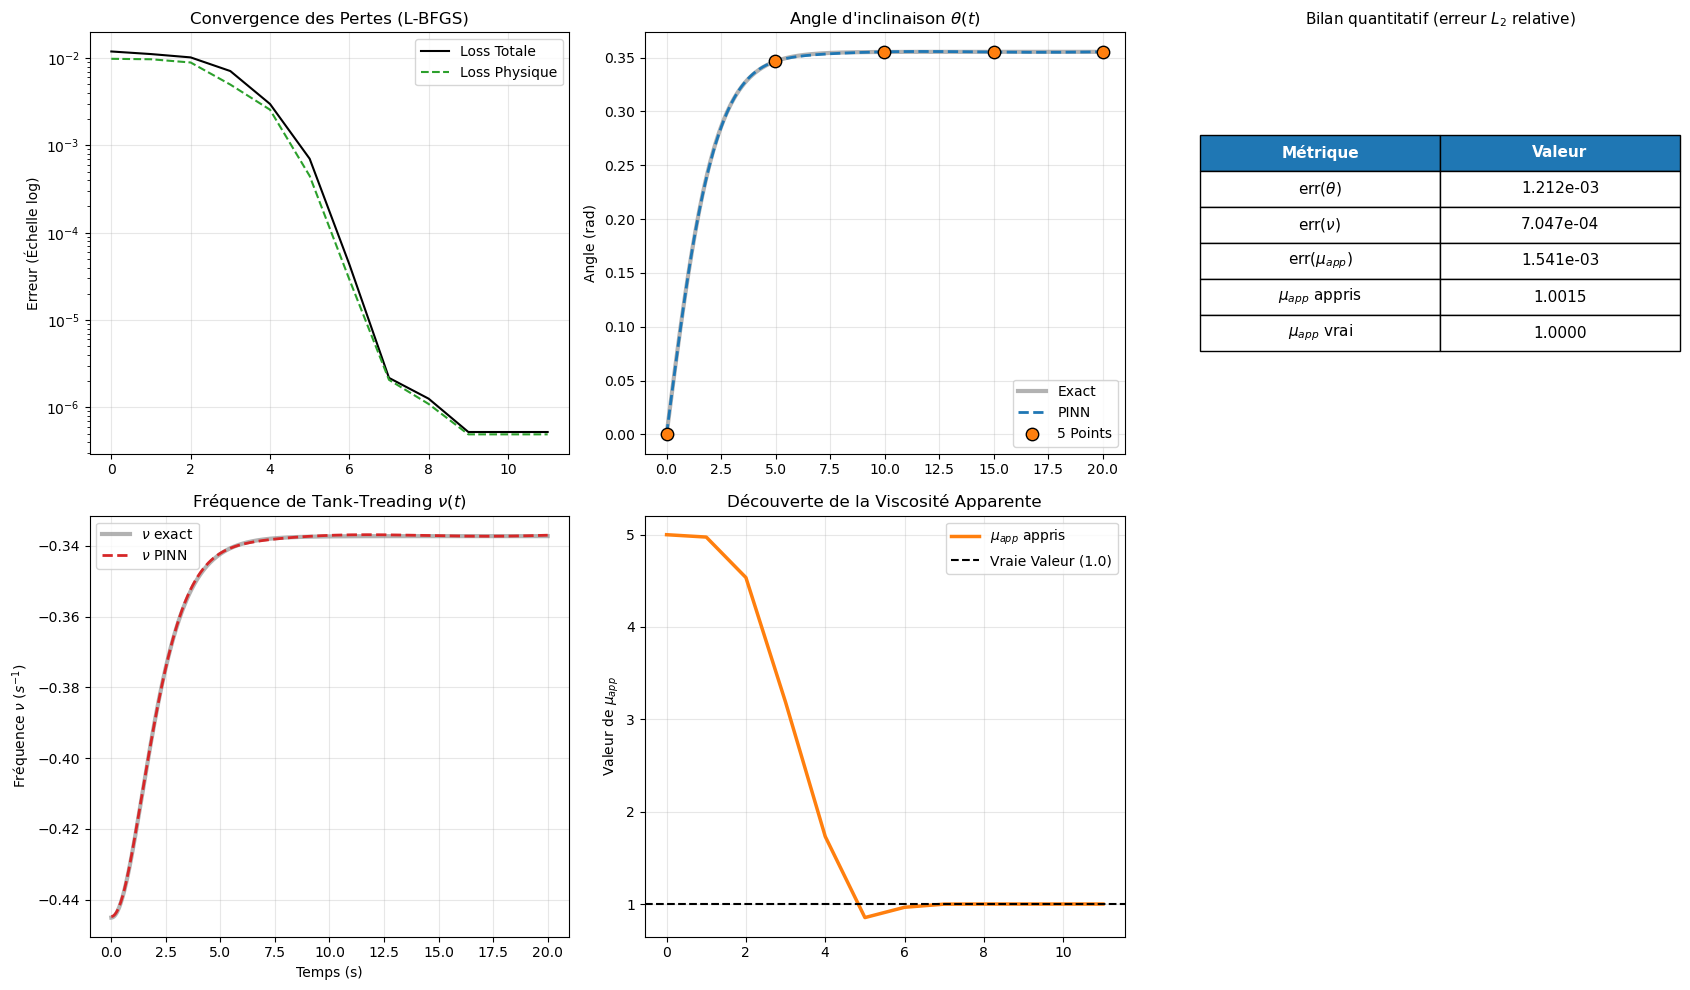

In [19]:
# =====================================================================
# ENTRAÎNEMENT PINN - PROBLÈME INVERSE (DÉCOUVERTE DE PARAMÈTRE)
# =====================================================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Passage obligatoire en double précision pour L-BFGS ---
torch.set_default_dtype(torch.float64)
# -----------------------------------------------------------

torch.manual_seed(123)
np.random.seed(123)


# =====================================================================
# 0. MÉTRIQUES QUANTITATIVES (définies une seule fois, tout en haut)
# =====================================================================
def l2_relative_error(pred, ref):
    """Erreur L2 relative : ||pred - ref||_2 / ||ref||_2.
    Si ||ref||_2 est quasi nul, on normalise par l'amplitude (max-min) à la place."""
    pred = np.asarray(pred).flatten()
    ref = np.asarray(ref).flatten()
    norm_ref = np.linalg.norm(ref)
    if norm_ref < 1e-8:
        amplitude = np.max(ref) - np.min(ref)
        return np.linalg.norm(pred - ref) / max(amplitude, 1e-8)
    return np.linalg.norm(pred - ref) / norm_ref


def print_and_save_metrics_ks_pur(test_name, theta_pinn, theta_ref, nu_pinn, nu_ref,
                                   mu_app_learned=None, mu_app_true=None,
                                   filename="metriques_tests.txt"):
    """Version KS pur (1 seule sortie theta, pas de omega). Calcule les erreurs
    L2 relatives sur theta et nu, + l'erreur relative sur mu_app si fournie
    (cas du problème inverse), et ajoute une ligne au fichier récapitulatif."""
    err_theta = l2_relative_error(theta_pinn, theta_ref)
    err_nu = l2_relative_error(nu_pinn, nu_ref)

    line = (f"{test_name:35s} | "
            f"err_theta = {err_theta:.3e} | "
            f"err_nu = {err_nu:.3e}")

    if mu_app_learned is not None and mu_app_true is not None:
        err_mu_app = abs(mu_app_learned - mu_app_true) / abs(mu_app_true)
        line += f" | err_mu_app = {err_mu_app:.3e} (appris={mu_app_learned:.4f}, vrai={mu_app_true:.4f})"

    print("\n=== Métriques quantitatives (erreur L2 relative) ===")
    print(line)

    with open(filename, "a") as f:
        f.write(line + "\n")

    return err_theta, err_nu


# =====================================================================
# 1. PARAMÉTRAGE ET CONSTANTES PHYSIQUES
# =====================================================================
a1, a2, a3 = 4.296, 1.229, 4.296
kappa = 1.0
mu = 2.0
theta0_val = 0.0

# La "Vraie" viscosité cachée (utilisée UNIQUEMENT pour générer les 5 points)
mu_app_TRUE = 1.0

# --- Le paramètre apprenable ---
mu_app_guess = torch.nn.Parameter(torch.tensor([5.0], dtype=torch.float64))

def calculate_ks_constants(a1, a2, a3):
    a0 = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/a0, a2/a0, a3/a0

    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)

    g3_prime, _ = quad(integrand, 0, np.inf)
    r2 = a2 / a1
    z1 = 0.5 * ((1/r2) - r2)
    z2 = g3_prime * (alpha1**2 + alpha2**2)

    f1 = (r2 - (1/r2))**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3, z1, r2

f1, f2, f3, z1, r2 = calculate_ks_constants(a1, a2, a3)

def calculate_physics_tensor(kappa, mu, mu_app_tensor, f1, f2, f3, z1, r2):
    A = -0.5 * kappa
    bracket_term = 1 / (f2 - (mu_app_tensor / mu) * f1)
    accolade_term = 0.5 + (1 / z1) * f3 * bracket_term
    B = 2 * kappa * accolade_term * (z1 / ((1 / r2) + r2))
    C_visc = f3 * bracket_term
    return A, B, C_visc

A_true = -0.5 * kappa
bracket_term_true = 1 / (f2 - (mu_app_TRUE / mu) * f1)
accolade_term_true = 0.5 + (1 / z1) * f3 * bracket_term_true
B_true = 2 * kappa * accolade_term_true * (z1 / ((1 / r2) + r2))
C_visc_true = f3 * bracket_term_true

# =====================================================================
# 2. GÉNÉRATION DE LA VÉRITÉ TERRAIN ET DES 5 POINTS
# =====================================================================
def exact_solution_theta(t, A, B, theta0=0.0):
    t_1d = t.flatten()
    if B > -A:
        sqrt_term = np.sqrt(B**2 - A**2)
        D = (sqrt_term * np.tan(theta0) + A + B) / (sqrt_term * np.tan(theta0) - A - B)
        exp_term = np.exp(2 * sqrt_term * t_1d)
        fraction_1 = (B + A) / sqrt_term
        fraction_2 = (D * exp_term + 1) / (D * exp_term - 1)
        theta_t = np.arctan(fraction_1 * fraction_2)
        return theta_t.reshape(-1, 1)
    else:
        sqrt_term = np.sqrt(A**2 - B**2)
        phase_init = np.arctan(np.tan(theta0) * sqrt_term / (A + B))
        theta_t = np.arctan(((A + B) / sqrt_term) * np.tan(sqrt_term * t_1d + phase_init))
        theta_t_continue = np.unwrap(2 * theta_t) / 2
        return theta_t_continue.reshape(-1, 1)

t_min, t_max = 0.0, 20.0
t_exact_np = np.linspace(t_min, t_max, 500).reshape(-1, 1)
y_exact_np = exact_solution_theta(t_exact_np, A_true, B_true, theta0=theta0_val)

t_exact = torch.tensor(t_exact_np, dtype=torch.float64)
y_exact = torch.tensor(y_exact_np, dtype=torch.float64)

N_total = len(t_exact)
indices_5_points = np.linspace(0, N_total - 1, 5).astype(int)

t_data = t_exact[indices_5_points].detach()
y_data = y_exact[indices_5_points].detach()

print(f"Indices sélectionnés : {indices_5_points}")
print(f"Temps t_data sélectionnés : {t_data.flatten().tolist()}")

# =====================================================================
# 3. DÉFINITION DU MODÈLE PINN ET OPTIMISEUR L-BFGS
# =====================================================================
class FCN(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=1, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh()
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation)
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation)
            for _ in range(N_LAYERS - 1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

model = FCN()

optimizer_lbfgs = torch.optim.LBFGS(
    list(model.parameters()) + [mu_app_guess],
    lr=0.1,
    max_iter=20,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)

N_pde = 200
t_physics = torch.linspace(t_min, t_max, N_pde, dtype=torch.float64).view(-1, 1).requires_grad_(True)
t_ic = torch.tensor([[0.0]], dtype=torch.float64, requires_grad=True)

loss_total_hist, loss_phys_hist, epoch_hist = [], [], []
mu_app_hist = []

# =====================================================================
# 4. BOUCLE D'ENTRAÎNEMENT L-BFGS PURE (PROBLÈME INVERSE)
# =====================================================================
print(f"\n=== Début Problème Inverse (L-BFGS Uniquement) ===")
print(f"Objectif : Retrouver mu_app = {mu_app_TRUE}")
print(f"Supposition initiale : mu_app = {mu_app_guess.item():.4f}\n")

epochs_lbfgs = 12
w_phys_final = 1.0

for epoch in range(epochs_lbfgs):
    loss_tracker = {'total': 0.0, 'phys': 0.0}

    def closure():
        optimizer_lbfgs.zero_grad()

        A_dyn, B_dyn, _ = calculate_physics_tensor(kappa, mu, mu_app_guess, f1, f2, f3, z1, r2)

        theta_pred = model(t_physics)
        dtheta_dt = torch.autograd.grad(theta_pred, t_physics, grad_outputs=torch.ones_like(theta_pred), create_graph=True)[0]
        physics_residu = dtheta_dt - (A_dyn + B_dyn * torch.cos(2 * theta_pred))
        loss_physics = torch.mean(physics_residu**2)

        theta_0_pred = model(t_ic)
        loss_x0 = torch.mean((theta_0_pred - theta0_val)**2)

        y_data_pred = model(t_data)
        loss_data = torch.mean((y_data_pred - y_data)**2)

        loss = 3.0 * loss_data + w_phys_final * loss_physics + loss_x0
        loss.backward()

        loss_tracker['total'] = loss.item()
        loss_tracker['phys'] = loss_physics.item()
        return loss

    optimizer_lbfgs.step(closure)

    loss_total_hist.append(loss_tracker['total'])
    loss_phys_hist.append(loss_tracker['phys'])
    mu_app_hist.append(mu_app_guess.item())
    epoch_hist.append(epoch)

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"L-BFGS Epoch {epoch+1:4d} | Loss: {loss_tracker['total']:.2e} | mu_app = {mu_app_guess.item():.4f}")

print(f"\nEntraînement terminé. Valeur trouvée : mu_app = {mu_app_guess.item():.4f} (Vraie : {mu_app_TRUE})")

# =====================================================================
# 5. RÉSULTATS, POST-TRAITEMENT
# =====================================================================
model.eval()
with torch.no_grad():
    theta_pinn = model(t_exact).numpy()

    _, _, C_visc_pred = calculate_physics_tensor(kappa, mu, mu_app_guess, f1, f2, f3, z1, r2)
    nu_pred = -C_visc_pred.item() * kappa * np.cos(2 * theta_pinn)
    nu_exact = -C_visc_true * kappa * np.cos(2 * y_exact_np)
model.train()


# =====================================================================
# 5bis. MÉTRIQUES FINALES (appelées UNE SEULE FOIS, juste ici)
# =====================================================================
err_theta, err_nu = print_and_save_metrics_ks_pur(
    f"KSpurInverse_mu{mu_app_guess.item():.0f}to{mu_app_TRUE:.0f}",
    theta_pinn, y_exact_np,
    nu_pred, nu_exact,
    mu_app_learned=mu_app_guess.item(),
    mu_app_true=mu_app_TRUE,
)

mu_app_learned_val = mu_app_guess.item()
err_mu_app = abs(mu_app_learned_val - mu_app_TRUE) / abs(mu_app_TRUE)


# =====================================================================
# 6. AFFICHAGE (grille passée de 2x2 à 2x3 pour ajouter le tableau
#    de métriques dans une case dédiée, sans toucher aux 4 graphiques)
# =====================================================================
fig = plt.figure(figsize=(17, 10))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(epoch_hist, loss_total_hist, label="Loss Totale", color="k")
ax1.plot(epoch_hist, loss_phys_hist, label="Loss Physique", color="tab:green", linestyle="--")
ax1.set_yscale('log')
ax1.set_ylabel("Erreur (Échelle log)")
ax1.set_title("Convergence des Pertes (L-BFGS)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(2, 3, 2)
ax2.plot(t_exact_np, y_exact_np, color="grey", linewidth=3, alpha=0.6, label="Exact")
ax2.plot(t_exact_np, theta_pinn, color="tab:blue", linestyle="--", linewidth=2, label="PINN")
ax2.scatter(t_data.numpy(), y_data.numpy(), color="tab:orange", s=80, edgecolors='k', zorder=5, label="5 Points")
ax2.set_title(r"Angle d'inclinaison $\theta(t)$")
ax2.set_ylabel("Angle (rad)")
ax2.grid(True, alpha=0.3)
ax2.legend()
# --- Tableau des métriques, case libre (position 3, haut-droite) ---
ax3 = plt.subplot(2, 3, 3)
ax3.axis("off")
table_data = [
    [r"err($\theta$)",       f"{err_theta:.3e}"],
    [r"err($\nu$)",          f"{err_nu:.3e}"],
    [r"err($\mu_{app}$)",    f"{err_mu_app:.3e}"],
    [r"$\mu_{app}$ appris",  f"{mu_app_learned_val:.4f}"],
    [r"$\mu_{app}$ vrai",    f"{mu_app_TRUE:.4f}"],
]
tbl = ax3.table(
    cellText=table_data,
    colLabels=["Métrique", "Valeur"],
    cellLoc="center",
    loc="center",
    colWidths=[0.5, 0.5],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold", color="white")
        cell.set_facecolor("tab:blue")
ax3.set_title("Bilan quantitatif (erreur $L_2$ relative)", fontsize=11)



ax4 = plt.subplot(2, 3, 4)
ax4.plot(t_exact_np, nu_exact, color="grey", linewidth=3, alpha=0.6, label="$\\nu$ exact")
ax4.plot(t_exact_np, nu_pred, color="tab:red", linestyle="--", linewidth=2, label="$\\nu$ PINN")
ax4.set_title(r"Fréquence de Tank-Treading $\nu(t)$")
ax4.set_xlabel("Temps (s)")
ax4.set_ylabel(r"Fréquence $\nu$ ($s^{-1}$)")
ax4.grid(True, alpha=0.3)
ax4.legend()

ax5 = plt.subplot(2, 3, 5)
ax5.plot(epoch_hist, mu_app_hist, color="tab:orange", linewidth=2.5, label="$\\mu_{app}$ appris")
ax5.axhline(y=mu_app_TRUE, color="k", linestyle="--", label=f"Vraie Valeur ({mu_app_TRUE})")
ax5.set_title("Découverte de la Viscosité Apparente")
ax5.set_ylabel("Valeur de $\\mu_{app}$")
ax5.grid(True, alpha=0.3)
ax5.legend()
# ax6 (position 6) laissée vide

plt.tight_layout()
plt.show()